In [ ]:
import warnings
warnings.filterwarnings("ignore")
import sys
import os
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
import umap
import ot
import scipy
import scipy.sparse as sp

os.environ["R_HOME"] = "/opt/conda/envs/sg_prism/lib/R"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [27]:
# Obtain the root directory of the current Notebook's location
project_root = os.path.abspath('../../../')
if project_root not in sys.path:
    sys.path.append(project_root)
print(f"Project root added to sys.path: {project_root}")

Project root added to sys.path: c:\SG\SG_PH.D_file\Code\1-PRISM


In [ ]:
# import spatial multi-omics data
dataset_file = '/mnt/msg/1-PRISM/0-dataset/1-human lymphoid organs/lymph/slice1/'

adata_omics1 = sc.read_h5ad(dataset_file + 'adata_RNA.h5ad')
adata_omics2 = sc.read_h5ad(dataset_file + 'adata_ADT.h5ad')
adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

In [ ]:
# 1) Save RAW (unprocessed) protein true data BEFORE any normalize/log1p
adata_omics2.layers["raw_data"] = adata_omics2.X.copy()

raw_X = adata_omics2.layers["raw_data"]
if sp.issparse(raw_X):
    raw_total_counts = np.asarray(raw_X.sum(axis=1)).ravel()
else:
    raw_total_counts = np.asarray(raw_X).sum(axis=1)

adata_omics2.obs["raw_total_counts"] = raw_total_counts

In [30]:
import PRISM
from PRISM.preprocess import clr_normalize_each_cell, pca

sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
adata_omics1 = adata_omics1[:, adata_omics1.var['highly_variable']]

# copy spatial imformation
adata_omics1.uns['spatial'] = adata_omics1.obsm['spatial']
adata_omics1.obs['array_row'] = adata_omics1.obsm['spatial'][:, 0]
adata_omics1.obs['array_col'] = adata_omics1.obsm['spatial'][:, 1]

# copy true data
adata_omics1.uns['true_data'] = adata_omics1.X.copy()

### Simulated partial alignment

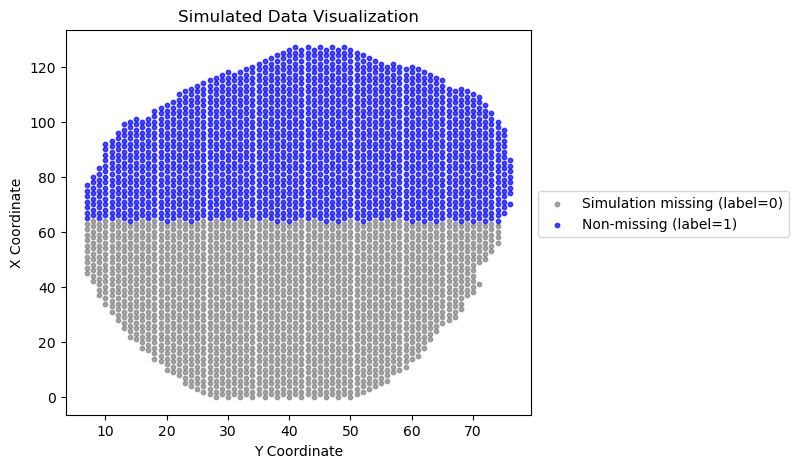

In [31]:
from PRISM.simulate import simulate_missing_sliding
ratio_m = 0.5 # Unregistered size(e.g.,50%)
ratio_s = 0.1 # Window size: each move is 10% of the total data size
step = 0      # 1 is a slide step (The default is 0: Unmove)
direction_tag = "H"  # H:"horizontal" or V:"vertical"

split1_indices = simulate_missing_sliding(
    adata_omics2,
    spatial_key="spatial",
    direction=direction_tag,
    missing_width=ratio_m,   
    step_ratio=ratio_s,     
    step_id=step,           
    label_key="missing",
    lock_at_end=True,
    plot=True
)

In [32]:
# Identify missing/non-missing indices
missing_indices = np.flatnonzero(adata_omics2.obs["missing"].to_numpy() == "0")
non_missing_indices = np.flatnonzero(adata_omics2.obs["missing"].to_numpy() == "1")

# Create independent copies for separate preprocessing
adata_missing = adata_omics2[missing_indices].copy()
adata_non_missing = adata_omics2[non_missing_indices].copy()

# Apply the same preprocessing pipeline to both subsets (normalize + log1p)
sc.pp.normalize_total(adata_missing, target_sum=1e4)
sc.pp.log1p(adata_missing)
sc.pp.normalize_total(adata_non_missing, target_sum=1e4)
sc.pp.log1p(adata_non_missing)
adata_omics2.X[missing_indices] = adata_missing.X
adata_omics2.X[non_missing_indices] = adata_non_missing.X

# Build and store the protein mask: 0 = missing, 1 = observed
protein_mask = np.zeros((adata_omics2.n_obs, adata_omics2.n_vars), dtype=np.float32)
protein_mask[non_missing_indices, :] = 1.0
adata_omics2.obsm["protein_mask"] = protein_mask

# Quick sanity checks
print("Mask shape:", adata_omics2.obsm["protein_mask"].shape)
print("Number of observed entries (label=1):", int((adata_omics2.obsm["protein_mask"] == 1).sum()))

Mask shape: (3484, 31)
Number of observed entries (label=1): 54002


In [33]:
adata_omics2.uns['true_data'] = adata_omics2.X.copy()
adata_omics2.X[missing_indices, :] = 0

In [34]:
if scipy.sparse.issparse(adata_omics1.X):
    adata_omics1.X = adata_omics1.X.toarray()
if scipy.sparse.issparse(adata_omics2.X):
    adata_omics2.X = adata_omics2.X.toarray()

if scipy.sparse.issparse(adata_omics1.uns['true_data']):
    adata_omics1.uns['true_data'] = adata_omics1.uns['true_data'].toarray()
if scipy.sparse.issparse(adata_omics2.uns['true_data']):
    adata_omics2.uns['true_data'] = adata_omics2.uns['true_data'].toarray()

In [35]:
# Load similarity matrix
sparse_matrix = sp.load_npz("../../2-Save_file/S1-AOT_distance.npz")
distance_matrix_6_gpu = sparse_matrix.toarray()
print("Matrix's shape is：", distance_matrix_6_gpu.shape)

Matrix's shape is： (3484, 3484)


------Calculating spatial graph...
The graph contains 27174 edges, 3484 cells.
7.7997 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 27174 edges, 3484 cells.
7.7997 neighbors per cell on average.


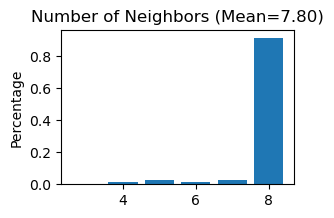

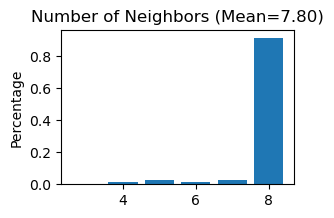

In [36]:
# Constructing Spatial Network for Omics1 and Omics2
PRISM.Cal_Spatial_Net(adata_omics1, rad_cutoff=2)
PRISM.Stats_Spatial_Net(adata_omics1)
PRISM.Cal_Spatial_Net(adata_omics2, rad_cutoff=2)
PRISM.Stats_Spatial_Net(adata_omics2)

In [ ]:
import ipynbname
# Use ipynbname to get the current notebook's name
code_name = ipynbname.name()

# Create the first part of the filename based on the notebook name and ratio
ratio_missing = int(ratio_m * 100)   
ratio_step = int(ratio_s * 100)      
dir_tag = str(direction_tag).strip().upper()  # H/V

#---------------------------------------------------------#
# Naming convention (example: "S1_R_H_unreg50%_s10%*1"):
#   - S1: slice ID (e.g., slice1)
#   - R : run code / experiment code (your notebook or pipeline identifier)
#   - H : direction tag (H = horizontal, V = vertical)
#   - uXX% : percentage of unregistered (missing) spots/cells (e.g., 50%)
#   - sYY% : sliding ratio per move (each move shifts the window by YY% of total cells)
#   - (k) : sliding step index (k-th move; 0 = no move, 1 = move once, 2 = move twice, ...)
first_name = f"{code_name}_{dir_tag}_u{ratio_missing}%_s{ratio_step}%({step})"
#---------------------------------------------------------#

save_path = "../../2-Save_file"  # Make sure this path matches your directory structure

# Start training with the provided parameters
adata1, adata2 = PRISM.train_PRISM(
    adata_omics1, 
    adata_omics2, 
    distance_matrix_6_gpu,
    k_top=5, 
    n_epochs=1000,            # Total number of training epochs
    output_dir=save_path,     # Directory to save the output files
    file_prefix=first_name,   # Prefix for the output filenames
    device=torch.device('cuda:1'),
    patience=50,              # Patience for early stopping
    min_epochs=20            # Minimum number of epochs before early stopping
)

### Task1: Spatial domain identification

fitting ...
  |======================================================================| 100%


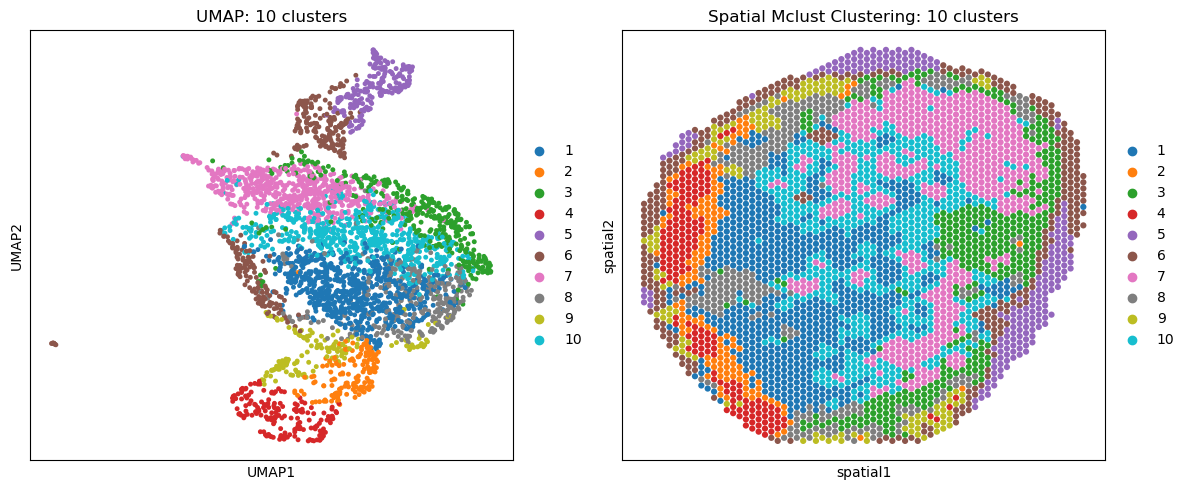

In [12]:
from PRISM.utils import clustering

# Step 1: Set tool and perform Mclust clustering (10 clusters)
tool = 'mclust'
# Perform Mclust clustering with 10 clusters
adata = adata_omics2.copy()
# adata = adata2.copy()
clustering(adata, key='PRISM_emb', add_key='PRISM_mclust', n_clusters=10, method=tool, use_pca=True)

# Step 2: UMAP visualization of the Mclust clustering results (10 clusters)
fig, ax_list = plt.subplots(1, 2, figsize=(12, 5))
sc.pp.neighbors(adata, use_rep='PRISM_emb', n_neighbors=10)
sc.tl.umap(adata)
sc.pl.umap(adata, color='PRISM_mclust', ax=ax_list[0], title='UMAP: 10 clusters', s=50, show=False)
sc.pl.embedding(adata, basis='spatial', color='PRISM_mclust', ax=ax_list[1], title='Spatial Mclust Clustering: 10 clusters', s=80, show=False)
plt.tight_layout()
plt.show()

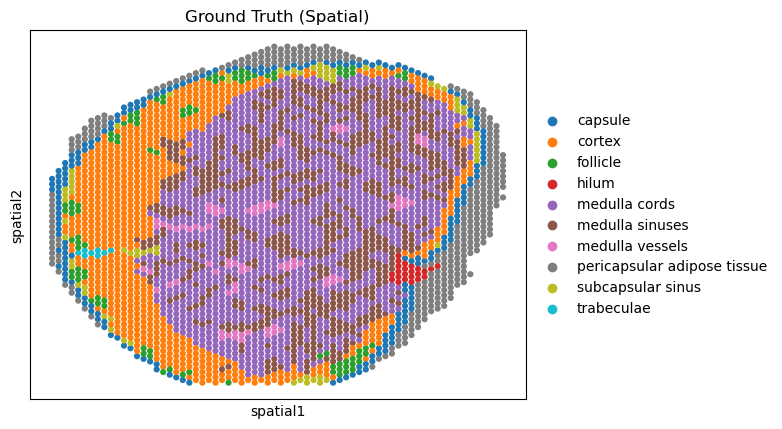

In [ ]:
sc.pl.embedding(adata, basis='spatial', color='final_annot', title='Ground Truth (Spatial)', s=80)

In [13]:
from PRISM.Validation import evaluate

# Prepare the true labels and remove 'NAN'
adata.obs['true_labels'] = adata.obs['final_annot']
adata_filtered = adata[~adata.obs['true_labels'].isna()].copy()
true_labels = adata_filtered.obs['true_labels']
mclust_labels = adata_filtered.obs['PRISM_mclust']

# Calculate metrics (e.g., NMI and ARI) for the Mclust 10 clustering results
ami_mclust, v_measure_mclust, mutual_info_mclust, homogeneity_mclust, nmi_mclust, ari_mclust = evaluate(true_labels, mclust_labels)
# Print the evaluation results on separate lines for clarity 
print(f"Mclust Clustering (10 clusters):")
print(f"AMI: {ami_mclust}, V-measure: {v_measure_mclust}")
print(f"Mutual Information: {mutual_info_mclust}, Homogeneity: {homogeneity_mclust}")
print(f"NMI: {nmi_mclust}, ARI: {ari_mclust}")

Mclust Clustering (10 clusters):
AMI: 0.3699040232605127, V-measure: 0.37383249473955954
Mutual Information: 0.7254775431598967, Homogeneity: 0.419923023387323
NMI: 0.3738324947395595, ARI: 0.20298567527484965


### Task2: Spatial omics imputaion (unregistered visualization)

In [39]:
from PRISM.Validation import prism_eval_and_save, plot_prism_imputation_spatial

# 只看 raw-space 的 PCC
res = prism_eval_and_save(
    adata=adata_omics2,             
    save_path=save_path,
    first_name=first_name,
    missing_indices=split1_indices,
    space="raw",                     # "processed" | "raw" | "both"
    metric="both",                    # "PCC" | "SPCC" | "both"
    save_files=True,
    # save_raw_imputed_all=False,
    # target_sum=1e4,
    # verbose=True
)


===== RAW (unprocessed counts) Evaluation Results =====
PCC : 0.6647
SPCC: 0.6326

Saved files:
 - raw_true_missing: ../../2-Save_file\S1_lymph_H_u50%_s10%(0)_unreg_raw_true.csv
 - raw_pred_missing: ../../2-Save_file\S1_lymph_H_u50%_s10%(0)_unreg_raw_pred.csv


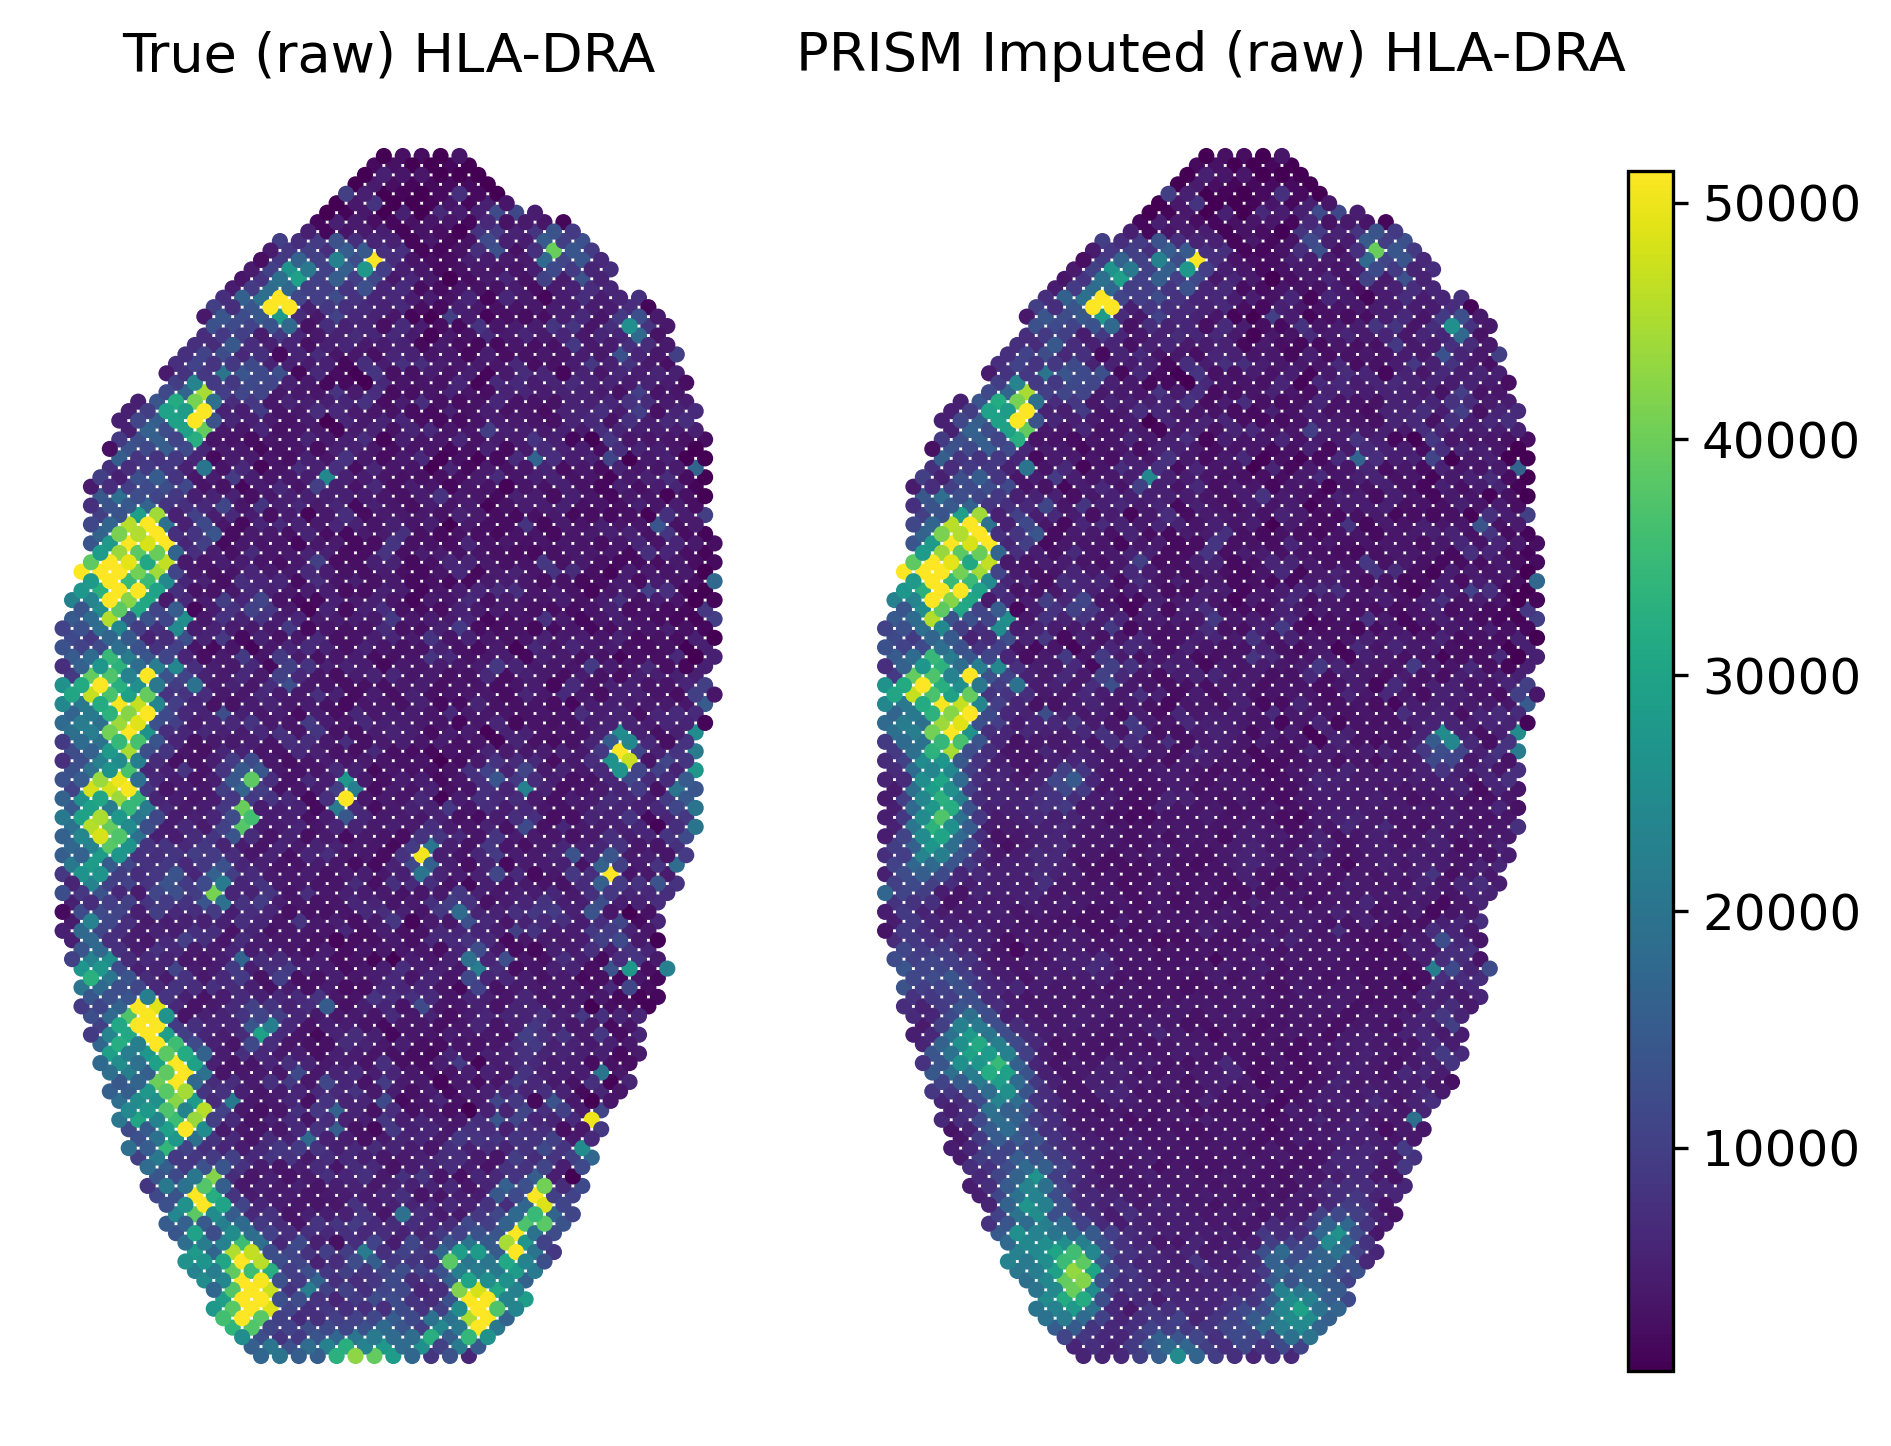

'HLA-DRA'

In [49]:
# VIM:3, HLA-DRA:8, CD3E:22
plot_prism_imputation_spatial(
    dataset_file=dataset_file,
    save_path=save_path,
    first_name=first_name,
    split1_indices=split1_indices,
    h5ad_name="adata_ADT.h5ad",
    feature=8, # VIM:3, HLA-DRA:8, CD3E:22
    # feature="VIM" 
    point_size=15,
    show_missing_only=False, 
    highlight_missing=False, # Set 'False' to make the interpolation performance more obvious.
    cbar_pos=(0.92, 0.05, 0.025, 0.8),
    cbar_ticksize=12,
    figsize=(6, 5),
    dpi=300,
    clip_quantiles=(0.01, 0.99)
)